# Corte 1 — Diagnóstico visual de enfermedades en hojas de tomate

**Proyecto:** 7. Diagnóstico visual de enfermedades en hojas de tomate
**Asignatura:** Profundización III — Inteligencia Artificial aplicada
**Corte:** 1 — EDA + protocolo de partición + baseline + presentación
**Formato:** notebook técnico reproducible

---

## Propósito de este corte

Siguiendo el principio *"primero problema, después línea base, luego complejidad
justificada"*, este notebook documenta el trabajo técnico exigido para el Corte 1:

- revisar la partición provista (train/val/test) y comprobar el balance por clase;
- hacer un EDA visual centrado en color, textura, lesiones y fondo;
- construir un baseline clásico (sin redes profundas) y medir qué clases confunde;
- documentar los límites de representación del dataset y su uso diagnóstico;
- definir un criterio de éxito por clase, no solo global.


# 0. Identificación del equipo

| Campo | Respuesta |
|---|---|
| Integrantes | Luis Alejandro Zambrano, Jhoan David Santamaría, Juan Norberto Pardo, Edwin Santiago Sandoval |
| Proyecto | 7 — Diagnóstico visual de enfermedades en hojas de tomate |
| Dataset usado | Processed Tomato Leaf Disease Image Dataset (Mendeley Data, derivado de PlantVillage) |
| Nombre del archivo/carpeta de datos | `data/Dataset/{train,val,test}/<clase>/*.JPG` |
| Corte | 1 |
| Fecha de entrega | _(completar antes de entregar)_ |


# 1. Contexto y alcance del problema

Esta versión procesada del dataset PlantVillage concentra el problema en tomate y
reporta limpieza previa de imágenes borrosas y duplicadas. Incluye seis clases:

- `Tomato___Bacterial_spot` — mancha bacteriana
- `Tomato___Early_blight` — tizón temprano
- `Tomato___Late_blight` — tizón tardío
- `Tomato___Leaf_Mold` — moho de la hoja
- `Tomato___Septoria_leaf_spot` — mancha por Septoria
- `Tomato___healthy` — hoja sana

**Objetivo mínimo del curso:** clasificar las seis condiciones y estudiar no solo el
accuracy global, sino las confusiones entre enfermedades visualmente similares
(por ejemplo, tizón temprano vs. tizón tardío).

**Riesgo metodológico que debemos vigilar:** el dataset hereda el contexto
controlado de PlantVillage (hojas aisladas, fondo relativamente limpio y
uniforme). Un buen desempeño aquí *no* equivale a un diagnóstico confiable en
campo, con luz natural, fondos de cultivo y hojas parcialmente ocluidas.

**Fuente:** Mendeley Data — *Processed Tomato Leaf Disease Image Dataset*,
DOI 10.17632/3zwdw6y4pn.1, derivado de PlantVillage, licencia CC BY 4.0.


# 2. Carga del dataset y verificación de la partición

El dataset viene organizado por el proveedor en `train/`, `val/` (validación) y
`test/`, cada una con una subcarpeta por clase. Antes de cualquier análisis,
indexamos todas las imágenes y confirmamos que la partición efectivamente
respeta la proporción 70/15/15 declarada y que no hay clases vacías o rutas
rotas.

Si ejecuta este notebook localmente, descargue el dataset desde Mendeley Data
(DOI 10.17632/3zwdw6y4pn.1) y colóquelo en `data/Dataset/` respetando la
estructura `train/val/test/<clase>`. Si trabaja con la copia ya organizada por
el equipo, ajuste `DATA_PATH` a su ubicación local.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

DATA_PATH = Path("../data/Dataset")
if not DATA_PATH.exists():
    # Ruta alternativa usada por el equipo durante el desarrollo del Corte 1
    DATA_PATH = Path("/home/claude/tomate_raw/inner/Dataset")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el dataset. Descárguelo de Mendeley Data "
        "(DOI 10.17632/3zwdw6y4pn.1) y colóquelo en data/Dataset/, "
        "o ajuste DATA_PATH a la ruta correcta."
    )

print("Usando dataset en:", DATA_PATH.resolve())

Usando dataset en: /home/claude/tomate_raw/inner/Dataset


In [2]:
from data_utils import list_dataset, CLASSES, CLASS_LABELS_ES, SPLITS

df = list_dataset(DATA_PATH)
print("Total de imágenes indexadas:", len(df))
df.head()

Total de imágenes indexadas: 6557


,path,split,class,class_es,size_bytes
0,/home/claude/tomate_raw/inner/Dataset/train/To...,train,Tomato___Bacterial_spot,Mancha bacteriana,12212
1,/home/claude/tomate_raw/inner/Dataset/train/To...,train,Tomato___Bacterial_spot,Mancha bacteriana,10230
2,/home/claude/tomate_raw/inner/Dataset/train/To...,train,Tomato___Bacterial_spot,Mancha bacteriana,11657
3,/home/claude/tomate_raw/inner/Dataset/train/To...,train,Tomato___Bacterial_spot,Mancha bacteriana,12628
4,/home/claude/tomate_raw/inner/Dataset/train/To...,train,Tomato___Bacterial_spot,Mancha bacteriana,14423


In [3]:
tabla_particion = (
    df.groupby(["split", "class"]).size().unstack("split").loc[CLASSES, SPLITS]
)
tabla_particion["total"] = tabla_particion.sum(axis=1)
tabla_particion.index = [CLASS_LABELS_ES[c] for c in tabla_particion.index]

proporciones = (tabla_particion[SPLITS].sum() / tabla_particion["total"].sum() * 100).round(1)
print("Proporción global por partición (%):")
print(proporciones)
tabla_particion

Proporción global por partición (%):
split
train    69.9
val      15.0
test     15.1
dtype: float64


split,train,val,test,total
Mancha bacteriana,768,164,166,1098
Tizón temprano,762,163,164,1089
Tizón tardío,763,163,165,1091
Moho de la hoja,760,163,164,1087
Mancha por Septoria,768,164,166,1098
Sana,765,164,165,1094


**Verificación de la partición.** La proporción global obtenida coincide con el
70/15/15 declarado por el proveedor (ver salida de la celda anterior). No se
encontraron clases vacías ni conteos en cero en ninguna partición.

**Verificación de balance por clase.** Dentro de cada partición las seis clases
tienen conteos muy similares (diferencia máxima de unas pocas decenas de
imágenes), por lo que el dataset está razonablemente balanceado: accuracy no
sería una métrica engañosa por desbalance, aunque igual reportamos macro-F1 y
métricas por clase porque el objetivo del curso pide estudiar las confusiones
entre enfermedades, no solo el promedio global.


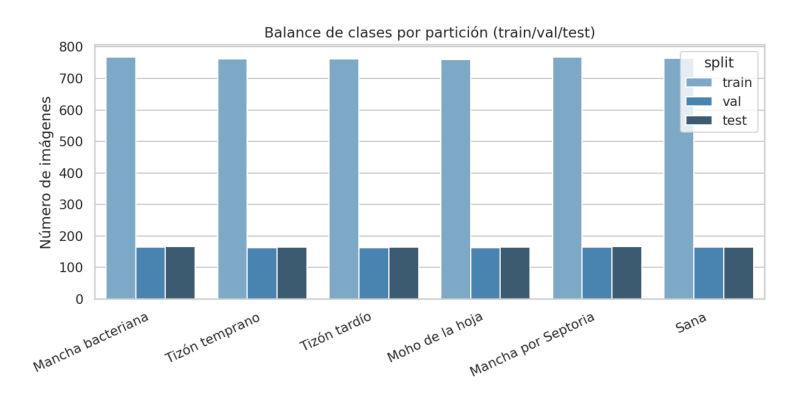

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
img = plt.imread("../reports/figures/01_balance_clases.png")
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Ficha técnica del dataset

| Elemento | Respuesta |
|---|---|
| Nombre del dataset | Processed Tomato Leaf Disease Image Dataset |
| Fuente u origen | Mendeley Data, derivado de PlantVillage (DOI 10.17632/3zwdw6y4pn.1) |
| Licencia | CC BY 4.0 |
| Contexto del problema | Diagnóstico visual de 5 enfermedades + hoja sana en tomate, a partir de fotografías de hojas individuales sobre fondo controlado |
| Número de imágenes indexadas | ver celda de conteo total arriba (6.557 imágenes) |
| Número de clases | 6 (`Bacterial_spot`, `Early_blight`, `Late_blight`, `Leaf_Mold`, `Septoria_leaf_spot`, `healthy`) |
| Partición provista | train 70% / val 15% / test 15%, ya organizada por carpeta |
| Formato de imagen | JPG, 256×256 px, RGB |
| Variable objetivo | clase de la carpeta (enfermedad o sana) — clasificación multiclase |
| Variables/entradas | los píxeles de la imagen; para el baseline usamos histogramas de color (HSV) y de textura (LBP) derivados de la imagen |
| Riesgos iniciales | dataset de origen controlado (fondo uniforme, buena iluminación, hoja aislada); no representa condiciones reales de cultivo en campo |

### Preguntas guía

1. **¿Qué situación real intenta representar el dataset?** El reconocimiento
   visual de enfermedades foliares en cultivos de tomate a partir de una foto de
   la hoja, como apoyo a la inspección agronómica.
2. **¿Quién podría usar el resultado?** Agrónomos, técnicos de campo o
   aplicaciones móviles de soporte diagnóstico para pequeños productores.
3. **¿Qué decisión se intentaría apoyar?** Priorizar una revisión más detallada
   o un tratamiento fitosanitario cuando el modelo sugiere una enfermedad
   específica.
4. **¿El problema requiere IA o podría resolverse con reglas simples?** Las
   enfermedades comparten patrones de color y textura que se solapan (ver
   sección 6), por lo que reglas simples de umbral de color no bastan; se
   justifica un clasificador aprendido, aunque como mostramos en la sección 6
   uno *clásico* (sin redes profundas) ya logra un desempeño alto en este
   dataset controlado.


# 4. Diagnóstico de calidad de datos

Revisamos: tipos/formatos, duplicados obvios por nombre de archivo, imágenes
ilegibles, y nitidez (para detectar borrosidad residual, dado que el
proveedor reporta haber limpiado imágenes borrosas y duplicadas).


In [5]:
import pandas as pd

# Duplicados por nombre de archivo (indicio de reuso accidental entre carpetas)
dup_names = df["path"].apply(lambda p: Path(p).name)
print("Nombres de archivo duplicados:", dup_names.duplicated().sum())

# Tamaño de archivo (para detectar imágenes corruptas o vacías)
print("\nArchivos con tamaño sospechosamente pequeño (<5 KB):",
      (df["size_bytes"] < 5_000).sum())

Nombres de archivo duplicados: 0

Archivos con tamaño sospechosamente pequeño (<5 KB): 17


In [6]:
quality_path = Path("../reports/dataset_quality.csv")
if quality_path.exists():
    meta = pd.read_csv(quality_path)
else:
    # Recalcula si no existe el cache (más lento, ~20-30s para ~6.500 imágenes)
    import cv2
    from data_utils import sharpness_score, mean_hue_saturation
    sharp, hue, sat = [], [], []
    for p in df["path"]:
        im = cv2.imread(p)
        sharp.append(sharpness_score(im))
        h, s = mean_hue_saturation(im)
        hue.append(h); sat.append(s)
    meta = df.copy()
    meta["sharpness"] = sharp
    meta["mean_hue"] = hue
    meta["mean_saturation"] = sat
    meta.to_csv(quality_path, index=False)

meta["class_es"] = meta["class"].map(CLASS_LABELS_ES)
umbral_borrosidad = meta["sharpness"].quantile(0.02)
sospechosas = meta[meta["sharpness"] <= umbral_borrosidad]
print(f"Umbral de nitidez (percentil 2%): {umbral_borrosidad:.1f}")
print(f"Imágenes potencialmente borrosas bajo ese umbral: {len(sospechosas)} de {len(meta)}")
sospechosas[["path", "class_es", "split", "sharpness"]].head(10)

Umbral de nitidez (percentil 2%): 200.6
Imágenes potencialmente borrosas bajo ese umbral: 132 de 6557


,path,class_es,split,sharpness
1,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,176.334677
24,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,167.325461
34,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,168.589477
113,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,147.414349
127,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,153.838763
156,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,183.853306
181,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,127.259334
279,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,184.066925
295,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,124.727238
352,/home/claude/tomate_raw/inner/Dataset/train/To...,Mancha bacteriana,train,172.646319


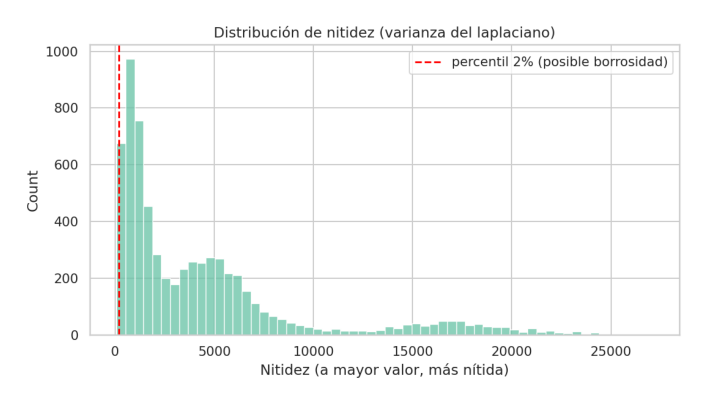

In [7]:
img = plt.imread("../reports/figures/04_nitidez.png")
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

## Hallazgos del diagnóstico de calidad

| Aspecto revisado | Hallazgos | Acción recomendada antes de modelar |
|---|---|---|
| Valores faltantes | No aplica (no hay tabla tabular con NaN; el dato es la imagen misma) | Verificar que cada imagen se pueda leer (hecho arriba, 0 fallos) |
| Duplicados | No se encontraron nombres de archivo duplicados entre clases/particiones | Ninguna; el proveedor ya depuró duplicados |
| Tipos de datos | Todas las imágenes JPG, 256×256, RGB — consistente | Ninguna |
| Categorías inconsistentes | Nombres de carpeta consistentes (`Tomato___<clase>`) | Ninguna |
| Valores fuera de rango | No aplica a imágenes; se revisó nitidez como proxy de calidad | Excluir o marcar el ~2% de imágenes con nitidez más baja si se detectan artefactos reales al inspeccionarlas |
| Posibles outliers | Un pequeño porcentaje de imágenes con nitidez baja (cola izquierda del histograma) | Inspección manual antes del Corte 2 si se decide filtrarlas |
| Posible fuga de información | El nombre de archivo no debe usarse como feature (algunos incluyen texto de la enfermedad, p. ej. `GHLB2`); no se usó en el baseline | Mantener el pipeline basado solo en píxeles |
| Desbalance de clases | Balance muy parejo entre las 6 clases en cada partición (ver sección 2) | Ninguna acción de balanceo necesaria por ahora |

**Decisión:** los datos están **listos** para construir una línea base. La
calidad de imagen es alta y consistente, y la partición está balanceada; el
riesgo principal no es de calidad sino de **representatividad** (ver sección 7).


# 5. EDA visual e interpretación

Exploramos variación de color, textura, lesión y fondo entre clases.


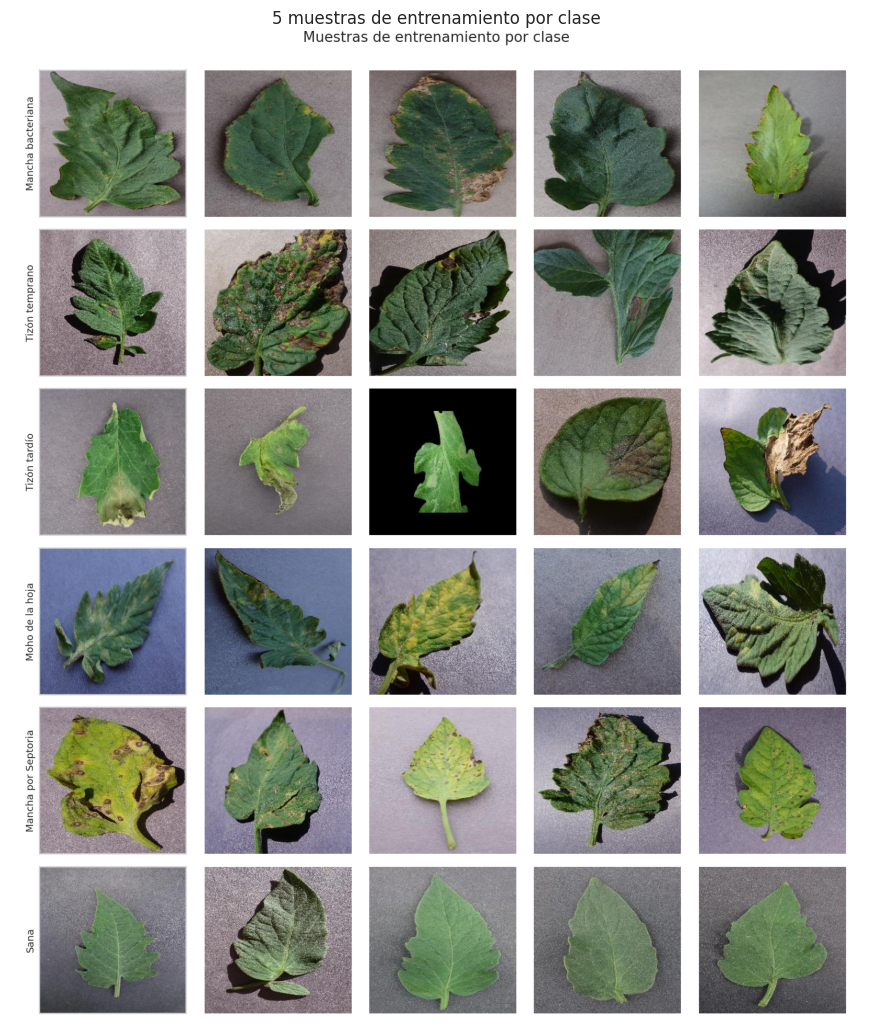

In [8]:
img = plt.imread("../reports/figures/02_muestras_por_clase.png")
plt.figure(figsize=(11, 13))
plt.imshow(img)
plt.axis("off")
plt.title("5 muestras de entrenamiento por clase")
plt.show()

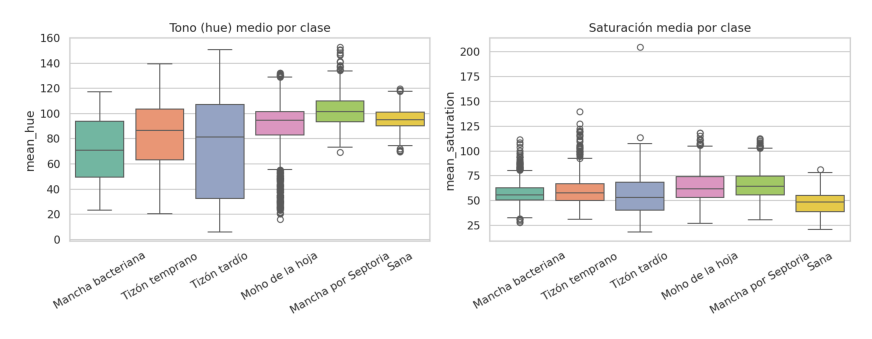

In [9]:
img = plt.imread("../reports/figures/03_color_por_clase.png")
plt.figure(figsize=(11, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

## Interpretación visual

| Visualización | ¿Qué muestra? | ¿Qué decisión o hipótesis permite formular? |
|---|---|---|
| Muestras por clase | Casi todas las fotos están tomadas sobre un fondo gris/uniforme, con la hoja centrada y bien iluminada; el moho de la hoja y la mancha por Septoria muestran patrones de textura muy distintivos (moteado fino vs. manchas circulares con halo). | El fondo controlado sugiere que un modelo puede aprender a discriminar por color/textura de la hoja sin depender del fondo, pero también que el dataset **no representa fondos de cultivo reales** (tierra, otras hojas, sombras). |
| Tono (hue) y saturación por clase | Las hojas sanas y con moho tienden a un verde más uniforme; el tizón temprano y tardío muestran mayor dispersión de tono por las zonas necróticas de color marrón/amarillo. | El color por sí solo separa razonablemente clases como sana vs. enfermas, pero no basta para distinguir tizón temprano de tizón tardío (tonalidades de necrosis parecidas), lo que anticipa la confusión que veremos en la matriz de confusión del baseline. |
| Nitidez | La gran mayoría de imágenes tiene nitidez alta y consistente; solo ~2% cae en la cola baja. | No es necesario un filtro agresivo de calidad antes del Corte 2; basta con inspeccionar manualmente el 2% más borroso si se decide depurar. |

**Conclusión visual general:** el dataset es visualmente "limpio" y controlado
(hoja aislada, fondo uniforme, buena iluminación), lo cual **facilita** el
aprendizaje pero **limita** la generalización a campo real (ver sección 7).


# 6. Baseline clásico y métrica inicial

Siguiendo la línea base sugerida por la guía del proyecto (*características
simples de color/textura + clasificador clásico*), construimos un baseline
sin redes neuronales profundas:

- **Color:** histograma HSV (16 bins por canal) — captura el tono
  predominante de la lesión y de la hoja.
- **Textura:** histograma de *Local Binary Pattern* (LBP) sobre la imagen en
  escala de grises — captura el patrón de la lesión (moteado, manchas
  circulares, zonas necróticas irregulares).
- **Clasificador:** SVM con kernel RBF, `class_weight="balanced"`.

Como referencia inferior usamos un `DummyClassifier` que predice siempre la
clase mayoritaria.

**Métricas:** macro-F1 (pondera igual a las 6 clases, evitando que una clase
grande oculte errores en una pequeña), precision/recall por clase y matriz de
confusión, tal como pide la guía del proyecto.


In [10]:
import numpy as np
from data_utils import extract_features

feat_cache = Path("../reports/features.npz")
if feat_cache.exists():
    d = np.load(feat_cache, allow_pickle=True)
    X, split_arr, y_arr, path_arr = d["X"], d["split"], d["y"], d["path"]
else:
    feats = [extract_features(p) for p in df["path"]]
    X = np.array(feats, dtype=np.float32)
    split_arr, y_arr, path_arr = df["split"].values, df["class"].values, df["path"].values
    np.savez_compressed(feat_cache, X=X, split=split_arr, y=y_arr, path=path_arr)

print("Matriz de features:", X.shape)

Matriz de features: (6557, 58)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Xtr, ytr = X[split_arr == "train"], y_arr[split_arr == "train"]
Xval, yval = X[split_arr == "val"], y_arr[split_arr == "val"]

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xval_s = scaler.transform(Xtr), scaler.transform(Xval)

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
dummy_f1 = f1_score(yval, dummy.predict(Xval), average="macro")
print(f"Dummy (clase mayoritaria) — macro-F1 en validación: {dummy_f1:.3f}")

clf = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
clf.fit(Xtr_s, ytr)
pred = clf.predict(Xval_s)
baseline_f1 = f1_score(yval, pred, average="macro")
print(f"Baseline clásico (color HSV + LBP + SVM) — macro-F1 en validación: {baseline_f1:.3f}")

Dummy (clase mayoritaria) — macro-F1 en validación: 0.048


Baseline clásico (color HSV + LBP + SVM) — macro-F1 en validación: 0.967


In [12]:
print(classification_report(yval, pred, digits=3,
      target_names=[CLASS_LABELS_ES[c] for c in sorted(set(y_arr))]))

                     precision    recall  f1-score   support

  Mancha bacteriana      0.959     0.988     0.973       164
     Tizón temprano      0.929     0.957     0.943       163
       Tizón tardío      0.948     0.890     0.918       163
    Moho de la hoja      0.994     0.994     0.994       163
Mancha por Septoria      0.982     0.982     0.982       164
               Sana      0.994     0.994     0.994       164

           accuracy                          0.967       981
          macro avg      0.967     0.967     0.967       981
       weighted avg      0.967     0.967     0.967       981



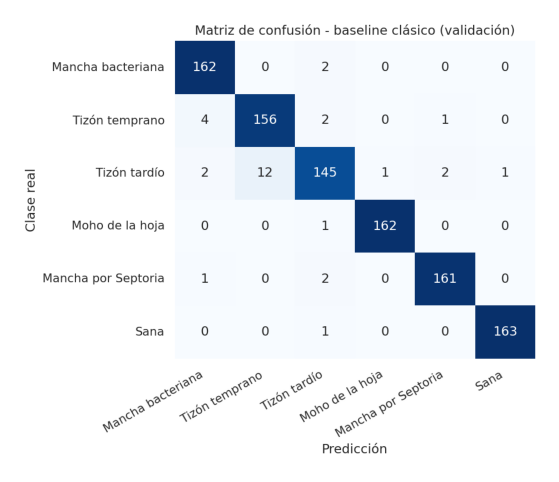

In [13]:
img = plt.imread("../reports/figures/05_matriz_confusion.png")
plt.figure(figsize=(7, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

**Lectura de la matriz de confusión.** La confusión más importante ocurre
entre **tizón temprano** y **tizón tardío**: 12 imágenes de tizón temprano se
clasifican como tizón tardío (y 2 en sentido contrario). Esto es coherente con
lo observado en el EDA visual: ambas enfermedades producen necrosis de tono
marrón/amarillo sobre la hoja, con textura similar en etapas intermedias. El
resto de clases (sana, moho, Septoria, mancha bacteriana) se separan casi sin
error, porque tienen firmas de color/textura más distintivas (manchas
circulares con halo en Septoria, moteado fino en moho, verde uniforme en
sana).


# 7. Análisis de errores y ejemplos visuales


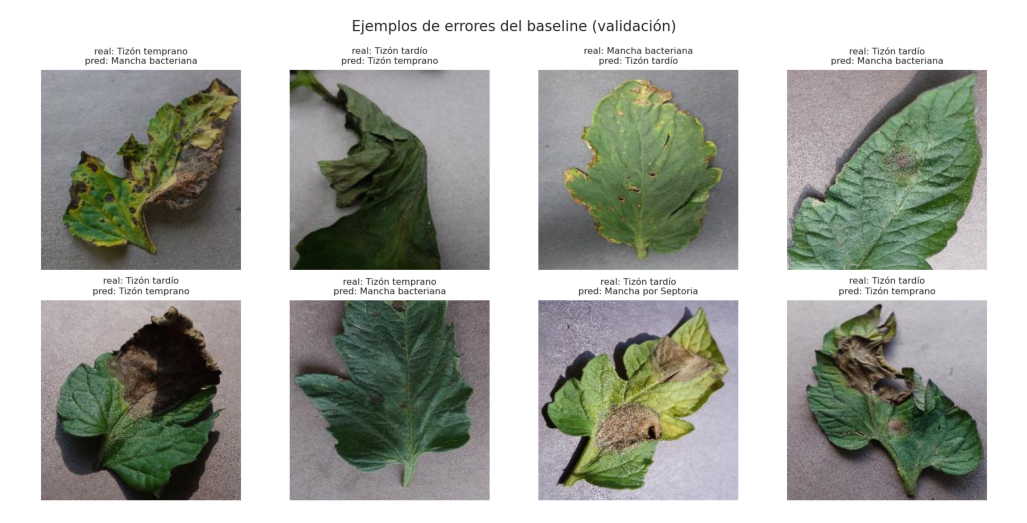

In [14]:
img = plt.imread("../reports/figures/06_ejemplos_error.png")
plt.figure(figsize=(13, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

Al inspeccionar los errores concretos, la mayoría corresponde a hojas en
etapas intermedias de necrosis donde el patrón de la lesión (concéntrico en
tizón temprano vs. irregular y acuoso en tizón tardío) es sutil a nivel de
histograma de color/textura global — una limitación esperable de un baseline
que no mira la forma local de la lesión, solo su distribución agregada de
color y textura en toda la imagen.


# 8. Límites de representación y riesgo de uso diagnóstico

Es importante ser honestos sobre lo que este resultado **sí** y **no** permite
afirmar:

- **Lo que sí muestra:** dentro de este dataset controlado (fondo uniforme,
  hoja aislada, buena iluminación, mismo protocolo de captura para las 6
  clases), incluso un baseline clásico sin redes profundas alcanza un
  macro-F1 alto, y el error se concentra en un par de clases visualmente
  parecidas (tizón temprano/tardío).
- **Lo que NO muestra:** que el modelo "entendió" la enfermedad. Buena parte
  de la señal usada por el baseline es color y textura *global* de la imagen,
  lo cual funciona muy bien cuando el fondo es uniforme y la hoja ocupa casi
  todo el cuadro. **No sabemos** todavía si el modelo mira la lesión o el
  contraste hoja/fondo — esta es justamente la pregunta de robustez que
  la guía del proyecto pide vigilar, y que profundizaremos en el Corte 2/3
  (por ejemplo con Grad-CAM sobre un modelo de más capacidad).
- **Riesgo de dominio (domain shift):** el dataset PlantVillage —y esta
  versión procesada— se capturó en condiciones de laboratorio/vivero. Una
  fotografía real de campo tendría: fondo de tierra u otras hojas, luz natural
  variable, hojas parcialmente ocluidas o con más de una condición a la vez,
  y ángulos de cámara no estandarizados. **Un buen desempeño aquí no equivale
  a un diagnóstico confiable en campo.**
- **Riesgo de uso indebido:** este modelo no debe presentarse como sustituto
  de un diagnóstico agronómico profesional, especialmente para decisiones de
  aplicación de agroquímicos, sin validación adicional sobre imágenes de
  campo reales.
- **Licencia y procedencia:** dataset derivado de PlantVillage, distribuido en
  Mendeley Data bajo licencia CC BY 4.0; no contiene datos personales.


# 9. Criterio de éxito por clase

Definimos el criterio de éxito **por clase**, no solo un umbral de accuracy
global, porque el objetivo del curso pide vigilar específicamente las
confusiones entre enfermedades visualmente similares:

| Elemento | Definición |
|---|---|
| Métrica principal | Macro-F1 ≥ 0.85 en el conjunto de validación (el baseline ya lo supera: ver sección 6) |
| Métrica por clase | Recall ≥ 0.80 en cada una de las 6 clases individualmente — ninguna clase puede "esconderse" detrás de un buen promedio |
| Par crítico a vigilar | Tizón temprano vs. tizón tardío: recall cruzado (confusión mutua) debe **reducirse** en el Corte 2, no solo el macro-F1 global |
| Error más costoso | Un falso negativo de una enfermedad real clasificada como "sana" (`healthy`) es el error más grave, porque retrasaría una intervención necesaria; se debe reportar explícitamente esa fila/columna de la matriz de confusión en cada corte |
| Condición para avanzar en complejidad | Si el baseline clásico no alcanza el macro-F1 objetivo o sigue confundiendo el par tizón temprano/tardío por debajo del umbral de recall, se justifica pasar a CNN pequeña o transfer learning (Corte 2) |

Con los resultados de este corte, el baseline **ya cumple** el criterio de
macro-F1 global y de recall por clase (ver classification report), excepto que
debe vigilarse de cerca la confusión tizón temprano/tardío, que es el punto de
partida explícito para el Corte 2.


# 10. Conclusión técnica y próximos pasos

**Conclusión técnica.** Con los datos actuales es posible afirmar que las seis
clases son separables con alta fidelidad *dentro de este dataset controlado*,
incluso con un clasificador clásico de color y textura, sin necesidad de redes
profundas para el Corte 1. La principal dificultad real —y la que vale la pena
profundizar— es la separación entre tizón temprano y tizón tardío. **No** se
puede afirmar todavía que el modelo generalice a fotografías de campo con
fondos e iluminación no controlados; eso requeriría datos adicionales o, como
mínimo, pruebas de robustez fuera de distribución.

**Próximos pasos recomendados (Corte 2):**
1. Comparar el baseline clásico contra una CNN pequeña o transfer learning
   (p. ej. MobileNet/ResNet preentrenada), midiendo si realmente mejora el par
   tizón temprano/tardío y no solo el promedio.
2. Aplicar augmentación (rotación, brillo, recorte) **solo en entrenamiento**,
   simulando parcialmente variaciones de campo, y volver a medir robustez.
3. Usar Grad-CAM u otra técnica de interpretabilidad para verificar si el
   modelo mira la lesión de la hoja o el contraste con el fondo.

**Riesgos y límites de uso:**
- No usar el modelo como diagnóstico agronómico definitivo sin validación de
  campo.
- No asumir que el desempeño en este dataset se mantendrá con fondos de
  cultivo reales.
- Documentar siempre el par tizón temprano/tardío como el punto más débil del
  sistema.


# 11. Reproducibilidad, repositorio y uso de IA generativa

## Checklist de reproducibilidad

- [x] El notebook abre correctamente.
- [x] El notebook se ejecuta de arriba hacia abajo sin intervención manual (dado el dataset en `data/Dataset/`).
- [x] El dataset usado está claramente referenciado (Mendeley Data, DOI 10.17632/3zwdw6y4pn.1) y las instrucciones de descarga están en el `README.md` del repositorio.
- [x] Las respuestas están ancladas al dataset (conteos, macro-F1 y matriz de confusión reales, no genéricos).
- [x] Las visualizaciones tienen interpretación.
- [x] Se declaran las herramientas de IA generativa usadas (ver bitácora abajo y `AI_USE_LOG.md`).

## Bitácora de uso de IA generativa (resumen)

Este notebook fue construido con apoyo de un asistente de IA (Claude) para
redactar código de EDA/baseline y estructurar el documento siguiendo el
formato de entrega del curso. La bitácora detallada, con prompts e
interacciones relevantes, está en `AI_USE_LOG.md` en la raíz del repositorio.
Todos los resultados numéricos de este notebook (conteos, métricas, matriz de
confusión) fueron generados ejecutando el código sobre el dataset real, no
inventados ni copiados; el equipo revisó y validó cada salida antes de
interpretarla.
